In [1]:
import numpy as np
import os
from importlib import reload
from multiprocessing import Pool
# from time import perf_counter

import functions.float_data_month_separation as fl_month
import functions.float_data_gridding as fl_grid
import pandas as pd
import xarray as xr
import scipy.stats as stats

## Set directories, make new directories if not created yet

In [ ]:
base_dir = "/Users/sethbushinsky/"
# base_dir = "/mnt/md0/seth/"
data_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Datasets/"
main_argo_dir = data_dir + 'Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/'
external_sharing_dir = main_argo_dir + '../for_external_sharing/gridded/'
home_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/"

code_version = 'v1.0_2026_08'

# check that home_dir exists
if not os.path.exists(home_dir):
    print(f"Error: home_dir {home_dir} does not exist.")
    exit(1)
intermediate_gridding_dir =main_argo_dir + f'../gridding_intermediate/{code_version}/non_bias_corrected/'
file_ending = 'Sprof_BGCArgoPlus_full.nc'

# intermediate_gridding_dir = main_argo_dir + '../gridding_intermediate/flag_only/'
# file_ending = 'Sprof_flags_mode_only.nc'

# var = 'DOXY_ADJUSTED_BGCArgoPlus'
vars_all = ['DOXY_ADJUSTED_BGCArgoPlus', 'NITRATE_ADJUSTED_BGCArgoPlus', 'DIC_BGCArgoPlus']
var_suffix_for_TSP = '_ADJUSTED_BGCArgoPlus'

for var in vars_all:

    if not os.path.exists(intermediate_gridding_dir):
        print(f"Creating directory: {intermediate_gridding_dir}")
        os.makedirs(intermediate_gridding_dir)
    else:
        print(f"Directory already exists: {intermediate_gridding_dir}")
    # create output directory if it doesn't exist
    monthly_nc_dir = intermediate_gridding_dir + var + '/'
    if not os.path.exists(monthly_nc_dir):
        print(f"Creating directory: {monthly_nc_dir}")
        os.makedirs(monthly_nc_dir)
    else:
        print(f"Directory already exists: {monthly_nc_dir}")

        csv_output_dir = monthly_nc_dir + 'monthly_CSVs/'
        if not os.path.exists(csv_output_dir):
            print(f"Creating directory: {csv_output_dir}")
            os.makedirs(csv_output_dir)
        else:
            print(f"Directory already exists: {csv_output_dir}")

Directory already exists: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/../gridding_intermediate/v0.1_2026_04/non_bias_corrected/
Directory already exists: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/../gridding_intermediate/v0.1_2026_04/non_bias_corrected/DOXY_ADJUSTED_BGCArgoPlus/
Directory already exists: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/../gridding_intermediate/v0.1_2026_04/non_bias_corrected/DOXY_ADJUSTED_BGCArgoPlus/monthly_CSVs/
Directory already exists: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/../gridding_intermediate/v0.1_2026_04/non_bias_corrected/
Directory already exists: /Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed/../gridding_intermediate/v0.

In [ ]:
# make monthly gridded folders for each variable:



## Find processed files, save out individual float data by month into .csv files for the target var

In [58]:
# find all processed float files
float_files = [f for f in os.listdir(main_argo_dir) if f.endswith(file_ending)]
print(len(float_files), 'float files found for gridding')

2427 float files found for gridding


In [ ]:
### Testing ###
file = '5901698_Sprof_BGCArgoPlus_full.nc'
argo_n = xr.open_dataset(main_argo_dir + file)
argo_n

year = 2015
month = 11

time_vals = pd.to_datetime(argo_n['JULD'].values)

month_inds = np.where((time_vals.year == year) & (time_vals.month == month))[0]
# month_inds

if len(month_inds) == 0:
    print('no month_inds found for', year, month)
argo_month = argo_n.isel(N_PROF=argo_n['N_PROF'][month_inds])
month_df = pd.DataFrame()
# for each profile in argo_month, create a dataframe, then concatenate all dataframes together
for p in range(len(argo_month['N_PROF'])):
    # if pressure is missing, skip
    if np.all(np.isnan(argo_month['PRES' + var_suffix_for_TSP].values[p,:])):
        print('Skipping profile', p, 'due to missing PRES' + var_suffix_for_TSP)
        continue
    df_dict = {'Float Number': str(argo_month['WMO_ID'].values), 
        'Datetime': pd.to_datetime(argo_month['JULD'].values[p]).strftime('%Y-%m-%d %H:%M:%S'),
        'LATITUDE': argo_month['LATITUDE'].values[p],
        'LONGITUDE': argo_month['LONGITUDE'].values[p],
        'PRES': argo_month['PRES' + var_suffix_for_TSP].values[p,:],
        'TEMP': argo_month['TEMP' + var_suffix_for_TSP].values[p,:],
        'PSAL': argo_month['PSAL' + var_suffix_for_TSP].values[p,:],
        'sigma': argo_month['sigma0'].values[p,:],
        'gamma': argo_month['gamma'].values[p,:],
        var: argo_month[var].values[p,:]
    }
    profile_df = pd.DataFrame(data=df_dict)


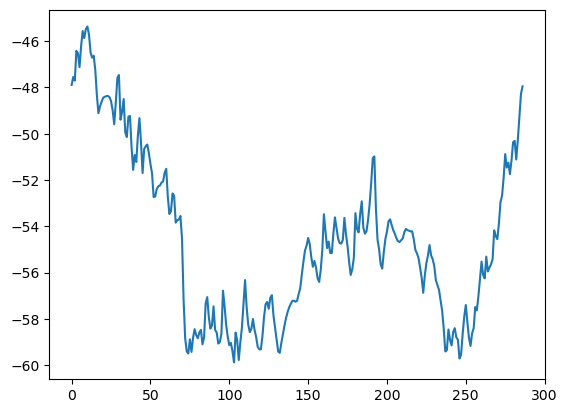

In [ ]:
### Testing ###

import matplotlib.pyplot as plt
plt.plot(argo_n['LATITUDE'].values)

In [ ]:
### Testing ###

# count number of profiles with missing PRES_ADJUSTED_BGCArgoPlus where PRES is not missing
missing_pres_count = 0
for p in range(len(argo_month['N_PROF'])):
    pres_data = argo_month['PRES' + var_suffix].values[p,:]
    if np.all(np.isnan(pres_data)) and not np.all(np.isnan(argo_month['PRES'].values[p,:])):
        missing_pres_count += 1
print('Number of profiles with missing PRES' + var_suffix + ' where PRES is not missing:', missing_pres_count)

Number of profiles with missing PRES_ADJUSTED_BGCArgoPlus where PRES is not missing: 38


### read in files, save by month

In [59]:
num_processes = 6 
var = 'DIC_BGCArgoPlus'
reload(fl_month)

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        float_month_sep_args = [(var, var_suffix_for_TSP, file, main_argo_dir, csv_output_dir) for n, file in enumerate(float_files)]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_month.float_month_separation, float_month_sep_args)
    


DIC_BGCArgoPlus not found in 5904036_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6903708_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 4902492_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6903826_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 3901068_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 5905229_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 4902571_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 2903165_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 5905381_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6901897_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6902814_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 1901218_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6902735_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6901183_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 6901235_Sprof_BGCArgoPlus_full.nc
DIC_BGCArgoPlus not found in 4902634_Sprof_BGCArgoPlus_

In [ ]:
## Testing ###
file = '4903622_Sprof_BGCArgoPlus_full.nc'  # test file

fl_month.float_month_separation(var, var_suffix_for_TSP, file, main_argo_dir, intermediate_gridding_dir)

Saved 2021_10_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2021_11_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2021_12_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_01_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_02_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_03_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_04_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_05_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_06_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_07_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_08_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_09_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_10_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_11_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2022_12_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2023_01_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2023_02_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2023_03_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2023_04_DOXY_ADJUSTED_BGCArgoPlus_4903622.csv
Saved 2023_0

## Prep for desired grid, then load in all data for each month and grid

In [5]:
# Set Bin Edges
binx=np.linspace(-179.5, 179.5, 360)
biny=np.linspace(-89.5, 89.5, 180)
binz=[0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 210, 230, 250, 270, 290, 310, 330, 350, 370, 390, 410, 430, 450, 470,
        525, 575, 625, 675, 725, 775, 825, 875, 925, 975, 1025, 1075, 1125, 1175, 1225, 1275, 1325, 1375, 1425, 1550, 1650, 1750, 1850, 1950, 2050]
bins=[binz, biny, binx]

targetx = np.linspace(-179, 179, 359)
targety = np.linspace(-89, 89,  179)
targetz = [(binz[i] + binz[i+1]) / 2 for i in range(len(binz)-1)]
# [2.5, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 
#             170.0, 180, 200.0, 220.0, 240.0, 260.0, 280.0, 300.0, 320.0, 340.0, 360.0, 380.0, 400.0, 420.0, 440.0, 460.0, 
#             500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 850.0, 900.0, 950.0, 1000.0, 1050.0, 1100.0, 1150.0, 1200.0, 
#             1250.0, 1300.0, 1350.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0]

In [50]:
gridded_dir

'/Users/sethbushinsky/UHM_Ocean_BGC_Group Dropbox/Datasets/Data_Products/BGC_ARGO_GLOBAL/2025_01_24/processed//../for_external_sharing/gridded/monthly/'

In [60]:
# find if some files have already beeen created
var = 'DIC_BGCArgoPlus'
monthly_nc_dir = intermediate_gridding_dir + var + '/'
csv_output_dir = monthly_nc_dir + 'monthly_CSVs/'

exisiting_monthly_nc_files = [f for f in os.listdir(monthly_nc_dir) if f.endswith('.nc')]
print(len(exisiting_monthly_nc_files), 'existing monthly nc files found for', var)

# number of month csv files:
existing_month_dirs = [f for f in os.listdir(csv_output_dir) if f!=".DS_Store"]
print(len(existing_month_dirs), 'existing monthly directories found for', var)

# find missing monthly nc files
missing_monthly_nc_files = []
for month_dir in existing_month_dirs:
    month_nc_file = month_dir + '/' + var + '_' + month_dir + '.nc'
    if month_nc_file not in exisiting_monthly_nc_files:
        missing_monthly_nc_files.append(month_nc_file)
print(len(missing_monthly_nc_files), 'missing monthly nc files for', var)

0 existing monthly nc files found for DIC_BGCArgoPlus
147 existing monthly directories found for DIC_BGCArgoPlus
147 missing monthly nc files for DIC_BGCArgoPlus


In [ ]:
reload(fl_grid)

var = 'DIC_BGCArgoPlus'
monthly_nc_dir = intermediate_gridding_dir + var + '/'
csv_output_dir = monthly_nc_dir + 'monthly_CSVs/'

num_processes = 6

description = f'Gridded monthly mean binned BGC Argo data for {var}'
encoding = {v: {"zlib": True, "complevel": 4} for v in [
    "Temperature", "Salinity", var]}

if __name__ == "__main__":
    
    with Pool(processes=num_processes) as pool:
        # Create a list of arguments for pool.starmap
        month_grid_args = [(mon_dir, csv_output_dir, var, bins, targetz, targety, targetx, description, encoding, monthly_nc_dir) for mon_dir in os.listdir(csv_output_dir) if mon_dir!=".DS_Store"]
        
        # Use pool.starmap with the list of arguments
        pool.starmap(fl_grid.month_grid, month_grid_args)
    

# var = 'NITRATE_ADJUSTED_BGCArgoPlus'

# monthly_nc_dir = intermediate_gridding_dir + var + '/'


9 float files found for 2014 10
82 float files found for 2018 12
40 float files found for 2016 8
2 float files found for 2013 9
2 float files found for 2013 8
40 float files found for 2016 7
58 float files found for 2017 6
58 float files found for 2017 7
27 float files found for 2016 1
131 float files found for 2022 7
64 float files found for 2017 9
18 float files found for 2015 10
131 float files found for 2022 6
177 float files found for 2023 1
92 float files found for 2019 12
239 float files found for 2024 10
9 float files found for 2014 11
18 float files found for 2015 5
2 float files found for 2013 6
40 float files found for 2016 9
114 float files found for 2022 1
93 float files found for 2021 2
189 float files found for 2023 9
184 float files found for 2023 8
18 float files found for 2015 11
179 float files found for 2023 7
1 float files found for 2012 12
41 float files found for 2016 6
133 float files found for 2022 9
101 float files found for 2021 5
94 float files found for 202

In [63]:

# load all .nc files and concatenate into one xarray dataset
ds_list = []
for mon_file in os.listdir(monthly_nc_dir):
    if mon_file.endswith('.nc'):
        ds = xr.open_dataset(monthly_nc_dir + mon_file)
        ds_list.append(ds)
ds_all = xr.concat(ds_list, dim='time')
ds_all
ds_all.to_netcdf(external_sharing_dir +  f'BGC_Argo_monthly_gridded_{var}_{code_version}.nc', encoding=encoding)

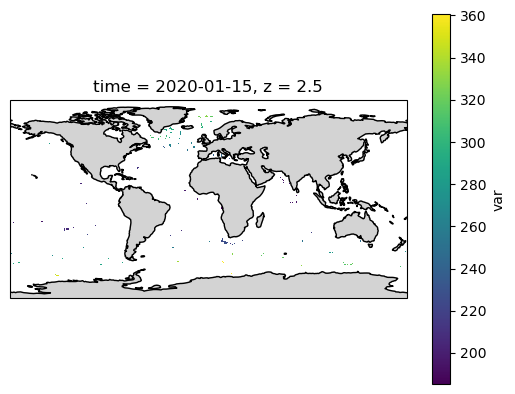

In [115]:
# checking one of the gridded data
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds['var'][0,0,:,:].squeeze().plot.pcolormesh(
    subplot_kws={'projection': ccrs.PlateCarree()},
    transform=ccrs.PlateCarree()
)
plt.gca().add_feature(cfeature.COASTLINE)
plt.gca().add_feature(cfeature.LAND, color='lightgray')

## OLD

In [4]:
# this will be separated into its own python script

# open a processed float file, look for variables in a passed list, save into monthly files for each variable

argo_n = xr.open_dataset(main_argo_dir + file)

# check for data and validity
var_list = argo_n.data_vars.keys()

if var in var_list: # check if variable exists in dataset
    if np.isnan(argo_n[var].values).all():
        print(f'no data, skipping {var} for {file}')
        # add a return here
else:
    print(f'{var} not found in {file}')
    # add a return here

# get years and months present in data file
time_vals = pd.to_datetime(argo_n['JULD'].values)
years = np.unique(time_vals.year)

# for each year, for each month with data in that year, save out a pandas dataframe as a csv with the data needed for gridding
for year in years:
    months = np.unique(time_vals[time_vals.year == year].month)
    for month in months:
        # print(month)
        month_inds = np.where((time_vals.year == year) & (time_vals.month == month))[0]
        # month_inds
        
        if len(month_inds) == 0:
            continue
        argo_month = argo_n.isel(N_PROF=argo_n['N_PROF'][month_inds])
        month_df = pd.DataFrame()
        # for each profile in argo_month, create a dataframe, then concatenate all dataframes together
        for p in range(len(argo_month['N_PROF'])):
            df_dict = {'Float Number': str(argo_month['WMO_ID'].values), 
                'Datetime': pd.to_datetime(argo_month['JULD'].values[p]).strftime('%Y-%m-%d %H:%M:%S'),
                'LATITUDE': argo_month['LATITUDE'].values[p],
                'LONGITUDE': argo_month['LONGITUDE'].values[p],
                'PRES': argo_month['PRES' + var_suffix].values[p,:],
                'TEMP': argo_month['TEMP' + var_suffix].values[p,:],
                'PSAL': argo_month['PSAL' + var_suffix].values[p,:],
                'sigma': argo_month['sigma0'].values[p,:],
                'gamma': argo_month['gamma'].values[p,:],

                var: argo_month[var].values[p,:]
            }
            profile_df = pd.DataFrame(data=df_dict)
            month_df = pd.concat((month_df, profile_df), axis=0, ignore_index=True)

        # drop rows with NaNs in the variable of interest
        month_df = month_df.dropna(subset=[var])
        # save to csv
        out_filename = f"{year}_{month:02d}_{var}_{str(argo_n['WMO_ID'].values)}.csv"
        # month_df.to_csv(out_filename, index=False)
        print(f'Saved {out_filename}')
        # if year_month_dir does not exist, create it
        month_path = intermediate_gridding_dir + var + '/' + f"{year}_{month:02d}" + '/'
        if not os.path.exists(month_path):
            os.makedirs(month_path)

        month_df.to_csv(month_path + out_filename, index=False)

<xarray.Dataset> Size: 32MB
Dimensions:                                     (N_PROF: 116, N_PARAM: 8,
                                                 N_CALIB: 1, N_LEVELS: 559)
Coordinates:
  * N_PROF                                      (N_PROF) int64 928B 0 1 ... 115
  * N_LEVELS                                    (N_LEVELS) int64 4kB 0 1 ... 558
    JULD                                        (N_PROF) datetime64[ns] 928B ...
    LATITUDE                                    (N_PROF) float64 928B ...
    LONGITUDE                                   (N_PROF) float64 928B ...
    PRES_ADJUSTED_BGCArgoPlus                   (N_PROF, N_LEVELS) float32 259kB ...
Dimensions without coordinates: N_PARAM, N_CALIB
Data variables: (12/159)
    DATA_TYPE                                   object 8B ...
    FORMAT_VERSION                              object 8B ...
    HANDBOOK_VERSION                            object 8B ...
    REFERENCE_DATE_TIME                         object 8B ...
    DATE_CREATION                               object 8B ...
    DATE_UPDATE                                 object 8B ...
    ...                                          ...
    pH_insitu_corr_ADJUSTED_BGCArgoPlus         (N_PROF, N_LEVELS) float64 519kB ...
    bias_corr_ADJUSTED_BGCArgoPlus              (N_PROF, N_LEVELS) float64 519kB ...
    TALK_BGCArgoPlus                            (N_PROF, N_LEVELS) float64 519kB ...
    DIC_BGCArgoPlus                             (N_PROF, N_LEVELS) float64 519kB ...
    PCO2_BGCArgoPlus                            (N_PROF, N_LEVELS) float64 519kB ...
    DOXY_SAT                                    (N_PROF, N_LEVELS) float64 519kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2024-12-17T05:11:46Z creation (software version 1.1...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.18 (version 11.01.2024 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

In [65]:
# trim the decimal seconds from the JULD values for saving
# pd.to_datetime(argo_month['JULD'].values[p]).strftime('%Y-%m-%d %H:%M:%S')
# or just use   
pd.to_datetime(argo_month['JULD'].values[p]).strftime('%Y-%m-%d %H:%M:%S')


'2024-01-21 18:09:11'

In [66]:
argo_month = argo_n.isel(N_PROF=argo_n['N_PROF'][month_inds])
month_df = pd.DataFrame()
# for each profile in argo_month, create a dataframe, then concatenate all dataframes together
for p in range(len(argo_month['N_PROF'])):
    df_dict = {'Float Number': str(argo_month['WMO_ID'].values), 
        'Datetime': pd.to_datetime(argo_month['JULD'].values[p]).strftime('%Y-%m-%d %H:%M:%S'),
        'LATITUDE': argo_month['LATITUDE'].values[p],
        'LONGITUDE': argo_month['LONGITUDE'].values[p],
        'PRES': argo_month['PRES' + var_suffix].values[p,:],
        'TEMP': argo_month['TEMP' + var_suffix].values[p,:],
        'PSAL': argo_month['PSAL' + var_suffix].values[p,:],
        'sigma': argo_month['sigma0'].values[p,:],
        'gamma': argo_month['gamma'].values[p,:],

        var: argo_month[var].values[p,:]
    }
    profile_df = pd.DataFrame(data=df_dict)
    month_df = pd.concat((month_df, profile_df), axis=0, ignore_index=True)

# drop rows with NaNs in the variable of interest
month_df = month_df.dropna(subset=[var])
# save to csv
out_filename = f"{year}_{month:02d}_{var}_{str(argo_n['WMO_ID'].values)}.csv"
# month_df.to_csv(out_filename, index=False)
print(f'Saved {out_filename}')
# if year_month_dir does not exist, create it
month_path = intermediate_gridding_dir + var + '/' + f"{year}_{month:02d}" + '/'
if not os.path.exists(month_path):
    os.makedirs(month_path)

month_df.to_csv(month_path + out_filename, index=False)

In [27]:
print(year)
print(month)
month_inds

print(time_vals[month_inds])

2024
1
DatetimeIndex(['2024-01-01 03:32:42.000368128',
               '2024-01-11 10:50:30.001145856',
               '2024-01-21 18:09:11.001944576'],
              dtype='datetime64[ns]', freq=None)
